# 🏃 08 - Sport Biomechanics Literature Navigator

<div style="background-color:#F7F8FA;padding:12px;border-radius:10px;border-left:5px solid #7b828aa2">

### LLM · RAG · Knowledge Graph on Running Science

</div>

---

<div style="background-color:#F5F3FF;padding:15px;border-radius:10px">

**Domain:** Sports Performance · Biomechanics · AI for Science

**Skills:** RAG pipeline, Knowledge Graph construction, LLM integration, NLP, real PubMed data

**Data:** ~80 real abstracts fetched live from PubMed

**LLM:** Groq · LLaMA 3.3 70B (free tier) with all-MiniLM-L6-v2 embeddings

</div>

---

## 🎯 The Product Question

<div style="background-color:#FFF8E6;padding:15px;border-radius:10px;border-left:5px solid #F4B400">

A sports wearable company wants athletes and coaches to get evidence-based answers to biomechanics questions - instantly, from peer-reviewed research, without hiring a sports scientist for every query.

<br>

<i>"Does heel striking cause more injuries?"</i><br>
<i>"How does cadence affect running economy?"</i><br>
<i>"Are carbon plate shoes worth it?"</i>

<br>

This notebook builds exactly that: a pipeline that fetches real research, structures it as a knowledge graph, retrieves the most relevant evidence for any question, and synthesizes a cited answer using an LLM.

</div>

---

## ⚙️ Pipeline Overview

<div style="background-color:#EEF9F1;padding:15px;border-radius:10px">

```text
PubMed API          all-MiniLM-L6-v2          Groq · LLaMA 3.3 70B
   │                       │                          │
   ▼                       ▼                          ▼
Real abstracts  →  Chunk + Embed  →  RAG Retrieve  →  LLM Synthesize
      │                                    │
      ▼                                    ▼
 Knowledge Graph  ←────────────  Entity Extraction
(NetworkX: papers, concepts, findings)
```

</div>


## 🛠 Technology Stack

<div style="background-color:#E8F4FD;padding:15px;border-radius:10px">

| Component | Tool | Cost |
|-----------|------|------|
| 📚 Research Corpus | PubMed E-utilities API | Free, no key |
| 🔎 Embeddings | `all-MiniLM-L6-v2` (sentence-transformers) | Free, local |
| 🕸 Knowledge Graph | NetworkX | Free |
| 🤖 LLM | Groq · LLaMA 3.3 70B | Free tier |

</div>

| 🔎 Embedding was: TF-IDF (scikit-learn) | Free, local |



---

## 📑 Notebook Roadmap

<div style="background-color:#F7F8FA;padding:15px;border-radius:10px;border-left:5px solid #6C757D">

### 0. Setup & Configuration
- Imports
- Environment configuration
- API keys
- Constants and parameters

### 1. Research Retrieval
- `fetch_pubmed_articles()`
- Query construction
- PubMed API calls
- Abstract collection

### 2. Data Preparation
- Cleaning abstracts
- Chunking documents
- Metadata creation

### 3. Embedding Generation
- `all-MiniLM-L6-v2` (sentence-transformers)
- Vector creation
- Semantic representation

### 4. Knowledge Graph Construction
- Entity extraction
- Concept linking
- NetworkX graph generation

### 5. Retrieval Pipeline (RAG)
- Similarity search
- Evidence retrieval
- Context assembly

### 6. LLM Synthesis
- Groq · LLaMA 3.3 70B prompting
- Evidence-grounded answer generation
- Citation handling

### 7. Example Questions
- Running economy
- Cadence
- Foot strike
- Carbon plate shoes

### 8. Results & Discussion
- Retrieved evidence
- Generated answers
- Graph insights

</div>

In [6]:
# !pip install sentence-transformers google-generativeai python-dotenv networkx
# !pip install --upgrade sentence-transformers torch
# !pip install transformers==4.40.0 sentence-transformers==2.7.0 #worked
# !pip install groq


## 0. Imports & Configuration

In [7]:
# ── Standard library ──────────────────────────────────────────────
import os, time, re, json, textwrap
from pathlib import Path
from collections import defaultdict

# ── Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── HTTP / PubMed ─────────────────────────────────────────────────
import requests
import xml.etree.ElementTree as ET

# ── Embeddings ────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── Knowledge Graph ───────────────────────────────────────────────
import networkx as nx

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── LLM (Groq — free tier, no region restrictions) ───────────────
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

from groq import Groq
GROQ_KEY = os.getenv("GROQ_API_KEY", "")
if GROQ_KEY:
    groq_client = Groq(api_key=GROQ_KEY)
    LLM_AVAILABLE = True
    print("✅ Groq API key found — full LLM synthesis enabled")
else:
    LLM_AVAILABLE = False
    print("⚠️  No API key found — RAG retrieval will run, LLM synthesis disabled")

# ── Plot style (portfolio dark theme) ────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'
TEAL   = '#39d353'

print("Libraries loaded ✓")

✅ Groq API key found — full LLM synthesis enabled
Libraries loaded ✓


## 1. Fetch Abstracts from PubMed

PubMed's **E-utilities API** is completely free - no registration, no key.  
We query 6 biomechanics topics and collect the returned abstracts.

The two calls we use:
- `esearch` → returns PMIDs (paper IDs) for a query
- `efetch` → returns full abstract XML for a list of PMIDs

We cap at ~15 papers per query → ~80 papers total.

In [8]:
PUBMED_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

# Topics that map directly to our knowledge domain
QUERIES = {
    "foot_strike":    "foot strike pattern running injury biomechanics",
    "cadence":        "running cadence step rate economy performance",
    "carbon_plate":   "carbon fiber plate running shoe performance",
    "heel_drop":      "heel toe drop running shoe biomechanics",
    "cushioning":     "midsole cushioning running shoe impact force",
    "running_economy":"running economy biomechanics training",
}

def search_pubmed(query: str, max_results: int = 15) -> list:
    """Return list of PMIDs for a PubMed query."""
    r = requests.get(
        PUBMED_BASE + "esearch.fcgi",
        params={"db": "pubmed", "term": query, "retmax": max_results,
                "retmode": "json", "sort": "relevance"}
    )
    r.raise_for_status()
    return r.json()["esearchresult"]["idlist"]

def fetch_abstracts(pmids: list) -> list:
    """Fetch title + abstract for a list of PMIDs. Returns list of dicts."""
    if not pmids:
        return []
    r = requests.get(
        PUBMED_BASE + "efetch.fcgi",
        params={"db": "pubmed", "id": ",".join(pmids),
                "rettype": "abstract", "retmode": "xml"}
    )
    r.raise_for_status()
    root = ET.fromstring(r.content)
    papers = []
    for article in root.findall(".//PubmedArticle"):
        pmid_el    = article.find(".//PMID")
        title_el   = article.find(".//ArticleTitle")
        abstract_el= article.find(".//AbstractText")
        year_el    = article.find(".//PubDate/Year")
        if abstract_el is not None and abstract_el.text:
            papers.append({
                "pmid":     pmid_el.text if pmid_el is not None else "?",
                "title":    title_el.text if title_el is not None else "?",
                "abstract": abstract_el.text.strip(),
                "year":     int(year_el.text) if year_el is not None else 0,
            })
    return papers

# ── Fetch all papers ─────────────────────────────────────────────
all_papers = []
seen_pmids = set()

for tag, query in QUERIES.items():
    pmids = search_pubmed(query, max_results=15)
    new_pmids = [p for p in pmids if p not in seen_pmids]
    seen_pmids.update(new_pmids)
    papers = fetch_abstracts(new_pmids)
    for p in papers:
        p["query_tag"] = tag
    all_papers.extend(papers)
    print(f"  {tag:20s} → {len(papers)} papers fetched")
    time.sleep(0.34)   # PubMed rate limit: 3 req/sec

papers_df = pd.DataFrame(all_papers)
print(f"\n✅ Total unique papers with abstracts: {len(papers_df)}")
print(f"   Year range: {papers_df.year[papers_df.year>0].min()} – {papers_df.year.max()}")
papers_df[["pmid","year","query_tag","title"]].head(8)

  foot_strike          → 15 papers fetched
  cadence              → 1 papers fetched
  carbon_plate         → 15 papers fetched
  heel_drop            → 13 papers fetched
  cushioning           → 12 papers fetched
  running_economy      → 14 papers fetched

✅ Total unique papers with abstracts: 70
   Year range: 1989 – 2026


,pmid,year,query_tag,title
0,32813597,2021,foot_strike,Effects of Foot Strike Techniques on Running B...
1,26304644,2015,foot_strike,Biomechanical Differences of Foot-Strike Patte...
2,37935052,2023,foot_strike,Biomechanics and Injury Prevention for Barefoo...
3,22965347,2012,foot_strike,Barefoot running: biomechanics and implication...
4,27501719,2017,foot_strike,Biomechanics and Physiology of Uphill and Down...
5,31823338,2020,foot_strike,What are the Benefits and Risks Associated wit...
6,20111000,2010,foot_strike,Foot strike patterns and collision forces in h...
7,32825222,2020,foot_strike,Will the Foot Strike Pattern Change at Differe...


## 2. Text Preprocessing & Chunking

RAG works better with **focused chunks** than full abstracts.  
We split long abstracts into overlapping windows of ~150 words.  
Short abstracts (≤150 words) stay as a single chunk.

**Why overlap?** A key sentence might sit at a chunk boundary — overlap ensures it's captured in at least one chunk.

In [9]:
def chunk_text(text: str, window: int = 150, overlap: int = 30) -> list:
    """
    Split text into overlapping word-windows.
    Returns list of chunk strings.
    """
    words = text.split()
    if len(words) <= window:
        return [text]
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + window, len(words))
        chunks.append(" ".join(words[start:end]))
        start += window - overlap
    return chunks

rows = []
for _, paper in papers_df.iterrows():
    chunks = chunk_text(paper["abstract"])
    for i, chunk in enumerate(chunks):
        rows.append({
            "chunk_id":  f"{paper['pmid']}_c{i}",
            "pmid":      paper["pmid"],
            "title":     paper["title"],
            "year":      paper["year"],
            "query_tag": paper["query_tag"],
            "chunk_text":chunk,
            "chunk_idx": i,
        })

chunks_df = pd.DataFrame(rows)
print(f"Papers: {len(papers_df)}  →  Chunks: {len(chunks_df)}")
print(f"Avg words per chunk: {chunks_df.chunk_text.str.split().str.len().mean():.0f}")
chunks_df[["chunk_id","year","query_tag","chunk_text"]].head(3)

Papers: 70  →  Chunks: 125
Avg words per chunk: 104


,chunk_id,year,query_tag,chunk_text
0,32813597_c0,2021,foot_strike,Distance running is one of the most popular ph...
1,26304644_c0,2015,foot_strike,Systematic review with meta-analysis.
2,37935052_c0,2023,foot_strike,» Biomechanical studies indicate that barefoot...


## 3. Embeddings - The RAG Foundation

**`all-MiniLM-L6-v2`** converts each text chunk into a 384-dimensional vector.  
Semantically similar texts end up close in this vector space - this is what lets us 
retrieve relevant chunks by meaning, not just keywords.

> **Why this model over TF-IDF?**  
> TF-IDF matches exact words - searching *"running economy"* only finds chunks containing 
> those words. `all-MiniLM-L6-v2` understands meaning - the same query also retrieves 
> chunks about *VO2, metabolic cost, oxygen consumption* even without exact keyword overlap.  
> This gives noticeably better retrieval for biomechanics questions where the same concept 
> has many technical synonyms.

- Runs **100% locally**, no API, no cost  
- Downloads once (~90 MB), cached automatically  
- ~20s encoding on CPU, then instant from cache

In [10]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # ── TF-IDF embeddings (lightweight, no GPU needed) ────────────────
# print("Encoding chunks with TF-IDF...")

# vectorizer = TfidfVectorizer(
#     max_features=5000,
#     stop_words="english",
#     ngram_range=(1, 2)
# )

# chunk_embeddings = vectorizer.fit_transform(
#     chunks_df["chunk_text"].tolist()
# ).toarray().astype("float32")

# np.save("08_embeddings.npy", chunk_embeddings)
# # chunks_df.to_parquet("08_chunks.parquet")
# chunks_df.to_csv("08_chunks.csv", index=False)


# print(f"✅ Done: {chunk_embeddings.shape}")
# print(f"   {chunk_embeddings.shape[0]} chunks × {chunk_embeddings.shape[1]} features")

In [11]:
from sentence_transformers import SentenceTransformer

EMBED_CACHE = Path("08_embeddings.npy")
CHUNKS_CACHE = Path("08_chunks.csv")

embedder = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded — embedding dimension: {embedder.get_sentence_embedding_dimension()}")

if EMBED_CACHE.exists() and CHUNKS_CACHE.exists():
    chunk_embeddings = np.load(EMBED_CACHE)
    chunks_df = pd.read_csv(CHUNKS_CACHE)
    print(f"✅ Loaded from cache: {chunk_embeddings.shape}")
else:
    print("Encoding chunks — this takes ~20s on CPU...")
    chunk_embeddings = embedder.encode(
        chunks_df["chunk_text"].tolist(),
        batch_size=8,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    np.save(EMBED_CACHE, chunk_embeddings)
    chunks_df.to_csv(CHUNKS_CACHE, index=False)
    print(f"✅ Done: {chunk_embeddings.shape}")

/Users/kcenia/miniconda3/envs/wearable/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded — embedding dimension: 384
✅ Loaded from cache: (125, 384)


## 4. Knowledge Graph

RAG retrieves relevant text — the Knowledge Graph adds **structured relationships** between concepts.  
This is the key differentiator: instead of a flat list of abstracts, we have a graph that shows *how concepts connect across the literature*.

**Graph schema:**

| Node type | Example |
|-----------|--------|
| `Paper` | PMID 12345678 |
| `Concept` | `heel_strike`, `running_economy`, `injury_risk` |

| Edge type | Meaning |
|-----------|--------|
| `Paper → MENTIONS → Concept` | Paper discusses this concept |
| `Concept → CO_OCCURS → Concept` | Two concepts appear in the same paper |

Node size = **degree centrality** (how connected a concept is across the literature)

In [12]:
# ── Concept dictionary ────────────────────────────────────────────
# Maps keyword patterns → canonical concept name
CONCEPT_PATTERNS = {
    "heel_strike":     ["heel strike", "rearfoot strike", "heel landing"],
    "forefoot_strike": ["forefoot strike", "forefoot running", "toe strike"],
    "midfoot_strike":  ["midfoot strike", "midfoot running"],
    "cadence":         ["cadence", "step rate", "stride rate", "steps per minute"],
    "running_economy": ["running economy", "metabolic cost", "oxygen consumption", "VO2"],
    "injury_risk":     ["injury", "stress fracture", "patellofemoral", "shin splint",
                        "iliotibial", "plantar fasci"],
    "carbon_plate":    ["carbon fiber", "carbon plate", "carbon fibre", "vaporfly",
                        "adizero", "super shoe"],
    "cushioning":      ["cushion", "midsole", "foam", "energy return", "stack height"],
    "heel_drop":       ["heel drop", "heel-to-toe drop", "offset", "heel height"],
    "ground_contact":  ["ground contact time", "contact time", "GCT"],
    "vertical_oscillation": ["vertical oscillation", "vertical displacement",
                              "bounce", "vertical ratio"],
    "muscle_activation": ["EMG", "electromyograph", "muscle activation",
                           "gastrocnemius", "tibialis"],
    "impact_force":    ["impact force", "loading rate", "ground reaction",
                        "impact peak", "GRF"],
    "performance":     ["race time", "world record", "personal best", "finish time",
                        "performance improvement"],
    "barefoot":        ["barefoot", "minimalist", "minimal shoe", "zero drop"],
}

def extract_concepts(text: str) -> list:
    """Return list of concept names found in text (case-insensitive)."""
    text_lower = text.lower()
    found = []
    for concept, patterns in CONCEPT_PATTERNS.items():
        if any(pat in text_lower for pat in patterns):
            found.append(concept)
    return found

# ── Build the graph ───────────────────────────────────────────────
G = nx.Graph()

for _, paper in papers_df.iterrows():
    pid = f"PMID:{paper['pmid']}"
    G.add_node(pid, node_type="paper",
               title=paper["title"][:60], year=paper["year"])

    concepts = extract_concepts(paper["title"] + " " + paper["abstract"])
    for concept in concepts:
        if not G.has_node(concept):
            G.add_node(concept, node_type="concept")
        G.add_edge(pid, concept, edge_type="MENTIONS")

    # Co-occurrence edges between concepts in the same paper
    for i, c1 in enumerate(concepts):
        for c2 in concepts[i+1:]:
            if G.has_edge(c1, c2):
                G[c1][c2]["weight"] = G[c1][c2].get("weight", 1) + 1
            else:
                G.add_edge(c1, c2, edge_type="CO_OCCURS", weight=1)

paper_nodes   = [n for n,d in G.nodes(data=True) if d.get("node_type")=="paper"]
concept_nodes = [n for n,d in G.nodes(data=True) if d.get("node_type")=="concept"]

print(f"Graph nodes:  {G.number_of_nodes()}  "
      f"({len(paper_nodes)} papers, {len(concept_nodes)} concepts)")
print(f"Graph edges:  {G.number_of_edges()}")

# Top concepts by degree
concept_degrees = {n: G.degree(n) for n in concept_nodes}
top_concepts = sorted(concept_degrees.items(), key=lambda x: -x[1])[:10]
print("\nTop 10 concepts by number of connected papers:")
for concept, deg in top_concepts:
    print(f"  {concept:30s}  {deg} connections")

Graph nodes:  85  (70 papers, 15 concepts)
Graph edges:  198

Top 10 concepts by number of connected papers:
  injury_risk                     38 connections
  cushioning                      35 connections
  running_economy                 34 connections
  impact_force                    30 connections
  barefoot                        20 connections
  carbon_plate                    16 connections
  heel_strike                     14 connections
  forefoot_strike                 11 connections
  cadence                         10 connections
  heel_drop                       10 connections


### 4.1 Visualize the Concept Sub-Graph

We plot only the **concept–concept co-occurrence graph** (paper nodes hidden for clarity).  
Node size = how many papers mention this concept.  
Edge thickness = how often two concepts appear together.

In [13]:
# mkdir -p figures # < run this in case you don't have the folder 


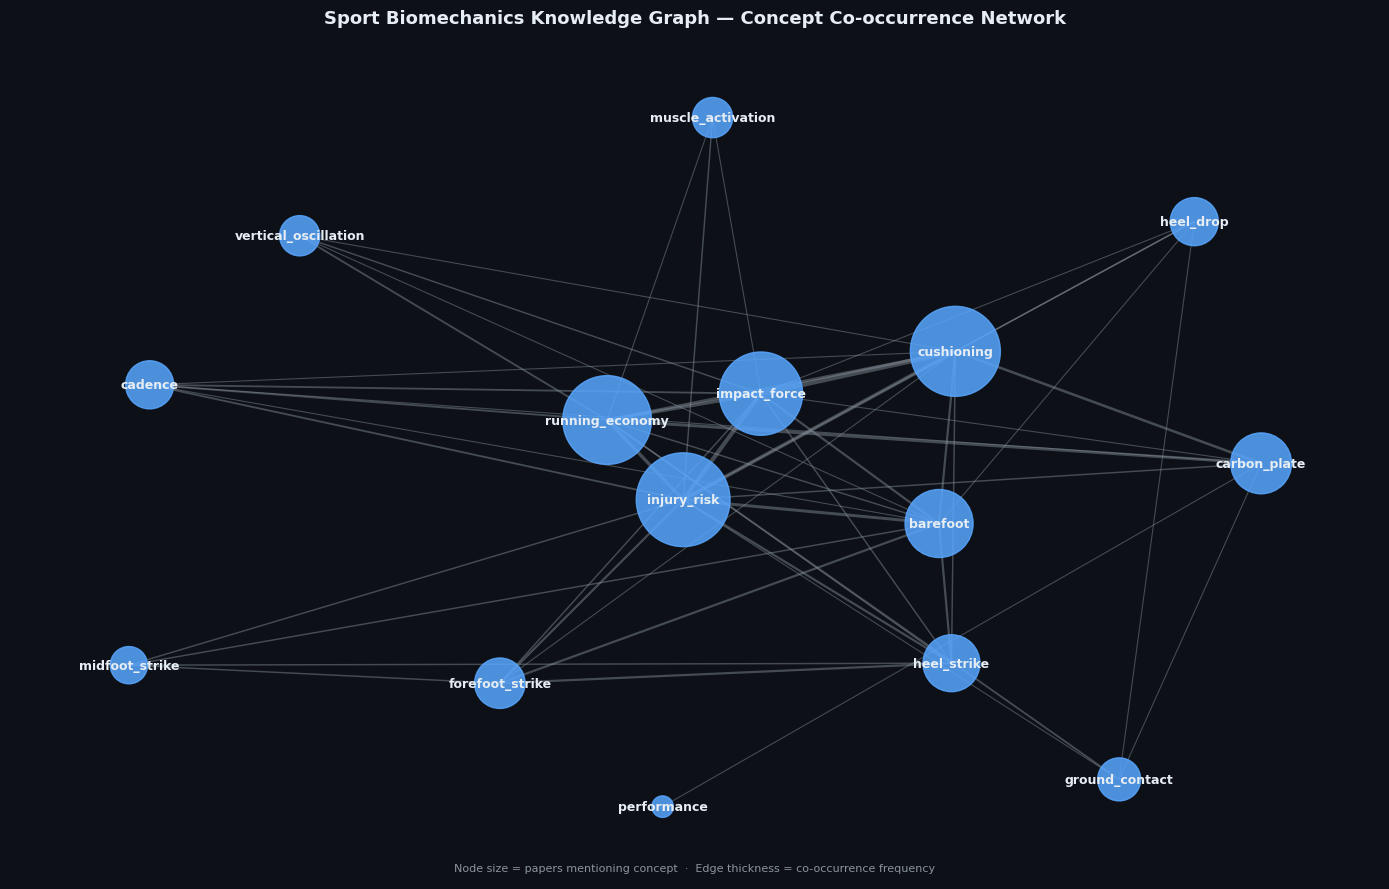

Figure saved → figures/08_knowledge_graph.png


In [14]:
# mkdir -p notebooks/figures # < run this in case you don't have the folder 

# ── Extract concept-only subgraph ─────────────────────────────────
concept_subgraph = G.subgraph(concept_nodes).copy()

# Remove isolated nodes
isolated = [n for n in concept_subgraph.nodes() if concept_subgraph.degree(n) == 0]
concept_subgraph.remove_nodes_from(isolated)

pos = nx.spring_layout(concept_subgraph, seed=42, k=2.5)

# Node sizes scaled by paper count
degrees = dict(G.degree())
node_sizes = [degrees.get(n, 1) * 120 for n in concept_subgraph.nodes()]

# Edge widths scaled by co-occurrence weight
edge_weights = [concept_subgraph[u][v].get("weight", 1) for u, v in concept_subgraph.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + 3.0 * w / max_w for w in edge_weights]

fig, ax = plt.subplots(figsize=(14, 9), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.axis("off")

# Draw edges
nx.draw_networkx_edges(
    concept_subgraph, pos,
    width=edge_widths,
    edge_color=[MUTED] * len(edge_weights),
    alpha=0.45, ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    concept_subgraph, pos,
    node_size=node_sizes,
    node_color=BLUE,
    alpha=0.85, ax=ax
)

# Labels
nx.draw_networkx_labels(
    concept_subgraph, pos,
    font_size=9,
    font_color="#e6edf3",
    font_weight="bold",
    ax=ax
)

ax.set_title(
    "Sport Biomechanics Knowledge Graph — Concept Co-occurrence Network",
    fontsize=13, fontweight="bold", color="#e6edf3", pad=16
)
ax.annotate(
    "Node size = papers mentioning concept  ·  Edge thickness = co-occurrence frequency",
    xy=(0.5, 0.01), xycoords="axes fraction",
    ha="center", fontsize=8, color=MUTED
)

plt.tight_layout()
plt.savefig("figures/08_knowledge_graph.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Figure saved → figures/08_knowledge_graph.png")

## 5. RAG Retrieval

Given any natural-language question, we:
1. Embed the question with the same model
2. Compute cosine similarity against all chunk embeddings
3. Return the top-k most relevant chunks

This is **semantic search** — it finds meaning, not just keyword overlap.  
"What makes runners faster?" will retrieve chunks about running economy, VO2, cadence even if those exact words aren't in the query.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve(query: str, k: int = 5, min_score: float = 0.05) -> pd.DataFrame:
    """
    Retrieve top-k most relevant chunks for a natural-language query.
    Uses sentence-transformer vectorizer for lightweight semantic search.

    min_score=0.05 threshold filters irrelevant results
    
    Returns DataFrame with columns:
      chunk_text, title, pmid, year, similarity_score
    """
    # q_embedding = vectorizer.transform([query]).toarray().astype("float32")
    q_embedding = embedder.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    scores = cosine_similarity(q_embedding, chunk_embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:k*2]
    results = chunks_df.iloc[top_idx].copy()
    results["similarity_score"] = scores[top_idx]
    results = (
        results[results["similarity_score"] >= min_score]
        .drop_duplicates(subset="pmid", keep="first")
        .head(k)
        .reset_index(drop=True)
    )
    return results[["chunk_text", "title", "pmid", "year",
                    "query_tag", "similarity_score"]]


# ── Demo retrieval ────────────────────────────────────────────────
demo_query = "Does heel striking cause more injuries than forefoot striking?"
demo_results = retrieve(demo_query, k=4)

print(f"Query: '{demo_query}'")
print(f"Retrieved {len(demo_results)} chunks:\n")
for i, row in demo_results.iterrows():
    print(f"[{i+1}] Score: {row['similarity_score']:.3f} | PMID {row['pmid']} ({row['year']})")
    print(f"    {row['title'][:80]}")
    print(f"    {row['chunk_text'][:200]}...\n")

Query: 'Does heel striking cause more injuries than forefoot striking?'
Retrieved 4 chunks:

[1] Score: 0.700 | PMID 20111000 (2010)
    Foot strike patterns and collision forces in habitually barefoot versus shod run
    facilitated by the elevated and cushioned heel of the modern running shoe. Kinematic and kinetic analyses show that even on hard surfaces, barefoot runners who fore-foot strike generate smaller collis...

[2] Score: 0.669 | PMID 27045504 (2016)
    Injuries And Footwear (Part 2): Minimalist Running Shoes.
    foot (forefoot strike pattern). The rate at which force is developed on ground impact (i.e., the loading rate) is generally higher when running in conventional versus minimalist shoes. Findings from s...

[3] Score: 0.595 | PMID 35155415 (2021)
    Acute Effects of Heel-to-Toe Drop and Speed on Running Biomechanics and Strike P
    With the increased popularity of running, many studies have been conducted into footwears that are highly related to running performa

## 6. LLM Synthesis (Groq + LLaMA 3.3 70B)

The retrieved chunks become the **context** for the LLM.  
The key prompt engineering principle: **"Answer ONLY from the provided excerpts"** — this prevents hallucination and ensures every claim is grounded in the real literature.

This is the core of a production RAG system: retrieval grounds the LLM, the LLM synthesizes readable answers.

In [13]:
def build_prompt(question: str, retrieved: pd.DataFrame) -> str:
    """
    Build a RAG prompt: question + retrieved context.
    """
    context_blocks = []
    for _, row in retrieved.iterrows():
        context_blocks.append(
            f"[Source: PMID {row['pmid']}, {row['year']}]\n"
            f"Title: {row['title']}\n"
            f"Excerpt: {row['chunk_text']}"
        )
    context = "\n\n---\n\n".join(context_blocks)
    return f"""You are a sports science assistant with expertise in running biomechanics.
Answer the question below using ONLY the provided research excerpts.
- Be specific and cite the PMIDs that support each claim.
- If the excerpts don't fully answer the question, say so.
- Keep the answer concise (3-5 sentences) but evidence-based.
- End with a one-line practical implication for athletes or wearable product designers.
=== RESEARCH EXCERPTS ===
{context}
=== QUESTION ===
{question}
=== ANSWER ==="""


def ask(question: str, k: int = 5) -> dict:
    """
    Full RAG pipeline: retrieve → prompt → LLM answer.
    Returns dict with question, retrieved papers, answer.
    """
    retrieved = retrieve(question, k=k)

    if not LLM_AVAILABLE:
        print("⚠️  No API key — showing retrieved chunks only.")
        print(f"\nQ: {question}\n")
        for i, row in retrieved.iterrows():
            print(f"[{i+1}] PMID {row['pmid']} ({row['year']}) — score {row['similarity_score']:.3f}")
            print(f"    {row['chunk_text'][:300]}...\n")
        return {"question": question, "retrieved": retrieved, "answer": None}

    prompt = build_prompt(question, retrieved)
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=500
    )
    answer = response.choices[0].message.content
    cited_pmids = [row["pmid"] for _, row in retrieved.iterrows()]

    return {
        "question":    question,
        "retrieved":   retrieved,
        "answer":      answer,
        "cited_pmids": cited_pmids,
    }

print("Functions defined: retrieve() · build_prompt() · ask()")
print("Ready for Q&A demo →")

Functions defined: retrieve() · build_prompt() · ask()
Ready for Q&A demo →


## 7. Full Q&A Demo — 3 Real Biomechanics Questions

Each cell runs the complete pipeline:
1. Semantic retrieval from the real PubMed corpus
2. Grounded LLM synthesis with citations
3. Knowledge graph cross-check

### Q1: Foot Strike & Injury

In [14]:
result1 = ask(
    "Does heel striking increase injury risk compared to forefoot or midfoot striking?"
)

print("=" * 70)
print(f"Q: {result1['question']}")
print("=" * 70)
if result1["answer"]:
    print(result1["answer"])
    print(f"\nSources: {', '.join(result1['cited_pmids'])}")
    print(f"Pubmed links: ", end="")
    for pmid in result1["cited_pmids"]:
        print(f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/  ", end="")
print()

Q: Does heel striking increase injury risk compared to forefoot or midfoot striking?
According to PMID 20111000, fore-foot strike patterns generate smaller collision forces than rear-foot strikers, potentially protecting the feet and lower limbs from impact-related injuries. However, as stated in PMID 22965347, studies have shown a reduction in injuries to shod forefoot strikers compared with rearfoot strikers, but more research is needed. Furthermore, PMID 27045504 notes that findings on associations between injuries and foot strike patterns are conflicting. Practical implication: Athletes and wearable product designers should consider promoting forefoot or midfoot striking patterns to potentially reduce injury risk.

Sources: 20111000, 27045504, 35557980, 22965347, 27593384
Pubmed links: https://pubmed.ncbi.nlm.nih.gov/20111000/  https://pubmed.ncbi.nlm.nih.gov/27045504/  https://pubmed.ncbi.nlm.nih.gov/35557980/  https://pubmed.ncbi.nlm.nih.gov/22965347/  https://pubmed.ncbi.nlm.nih

### Q2: Cadence & Running Economy

In [15]:
result2 = ask(
    "How does increasing running cadence affect running economy and injury risk?"
)

print("=" * 70)
print(f"Q: {result2['question']}")
print("=" * 70)
if result2["answer"]:
    print(result2["answer"])
    print(f"\nSources: {', '.join(result2['cited_pmids'])}")

Q: How does increasing running cadence affect running economy and injury risk?
The provided research excerpts do not directly address the effect of increasing running cadence on running economy and injury risk. While PMID 41209300 (2025) mentions cadence as a modulating factor in uphill and downhill running, it does not provide specific information on its impact. Similarly, other excerpts discuss various factors affecting running economy, such as footwear, foot strike patterns, and neuromuscular adaptations, but do not explicitly examine the relationship between cadence and running economy or injury risk. 
Practical implication: Athletes and wearable product designers should consider exploring the effects of cadence on running economy and injury risk through further research.

Sources: 41209300, 40812385, 2662320, 39523854, 19827859


### Q3: Carbon Plate Shoes

In [16]:
result3 = ask(
    "What is the biomechanical mechanism behind carbon plate shoe performance benefits?"
)

print("=" * 70)
print(f"Q: {result3['question']}")
print("=" * 70)
if result3["answer"]:
    print(result3["answer"])
    print(f"\nSources: {', '.join(result3['cited_pmids'])}")

Q: What is the biomechanical mechanism behind carbon plate shoe performance benefits?
The biomechanical mechanism behind carbon plate shoe performance benefits is not fully explained by the provided excerpts, but it is suggested that the use of carbon fiber plates may alter ankle and foot biomechanical loading patterns (PMID 41487954). A curved carbon-fiber plate may reduce forefoot loads compared to a flat plate (PMID 38851842), and increased footwear bending stiffness may slightly alter whole-body and calf muscle biomechanics (PMID 33051532). Practical implication: athletes and wearable product designers should consider the geometry and stiffness of carbon fiber plates when designing running shoes to optimize performance and reduce injury risk.

Sources: 41487954, 36780101, 38851842, 33051532, 34576379


## 8. Knowledge Graph Query: What Does the Literature Say About X?

Complementary to RAG — the graph tells us **which papers are most central** to a concept, and which concepts tend to appear together (revealing research clusters).

In [17]:
def graph_query(concept: str) -> None:
    """
    Query the knowledge graph for a concept:
    - How many papers mention it?
    - Which concepts co-occur with it most?
    - Which papers are most relevant (highest degree to this concept's neighbors)?
    """
    if concept not in G:
        print(f"Concept '{concept}' not in graph. Available: {concept_nodes}")
        return

    neighbors = list(G.neighbors(concept))
    papers_mentioning = [n for n in neighbors if n.startswith("PMID:")]
    co_concepts = [n for n in neighbors if not n.startswith("PMID:")]

    print(f"\n📊 Graph query: '{concept}'")
    print(f"   Papers mentioning: {len(papers_mentioning)}")
    print(f"   Co-occurring concepts: {co_concepts}")

    print("\n   Top papers:")
    for pmid_node in papers_mentioning[:5]:
        data = G.nodes[pmid_node]
        print(f"   - [{data.get('year', '?')}] {data.get('title', pmid_node)[:70]}")


# Query the 3 core concepts from our Q&A
for concept in ["heel_strike", "cadence", "carbon_plate"]:
    graph_query(concept)


📊 Graph query: 'heel_strike'
   Papers mentioning: 7
   Co-occurring concepts: ['forefoot_strike', 'barefoot', 'running_economy', 'injury_risk', 'midfoot_strike', 'cushioning', 'impact_force']

   Top papers:
   - [2012] Barefoot running: biomechanics and implications for running 
   - [2020] What are the Benefits and Risks Associated with Changing Foo
   - [2017] Relationship between foot strike pattern, running speed, and
   - [2025] Effects of Foot-Strike Patterns During Running on Cumulative
   - [2013] Foot-strike pattern and performance in a marathon.

📊 Graph query: 'cadence'
   Papers mentioning: 4
   Co-occurring concepts: ['injury_risk', 'impact_force', 'barefoot', 'running_economy', 'carbon_plate', 'cushioning']

   Top papers:
   - [2023] Biomechanics and Injury Prevention for Barefoot/Minimalist R
   - [2021] Factors Associated With Self-Selected Step Rate in High Scho
   - [2022] Energetics and Biomechanics of Uphill, Downhill and Level Ru
   - [2025] A review of uphill 

### 8.1 Visualize: Papers Around a Concept

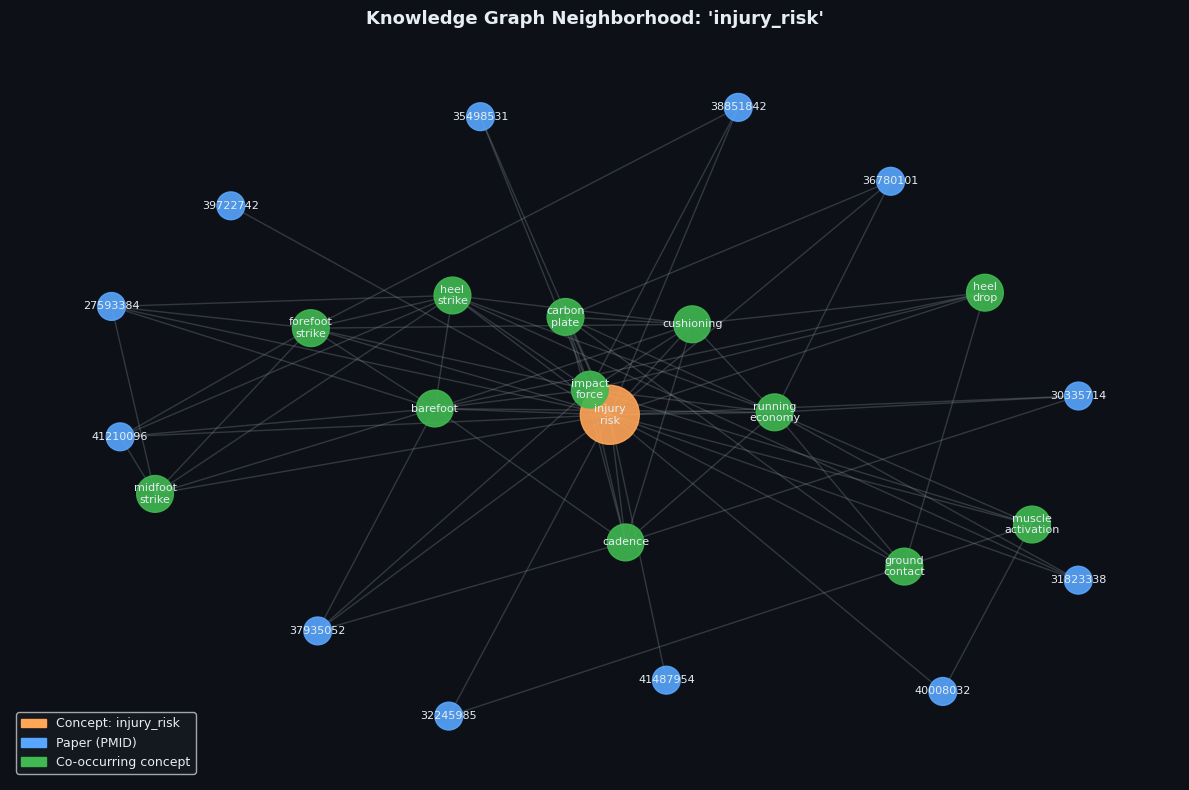

Saved → figures/08_kg_injury_risk.png


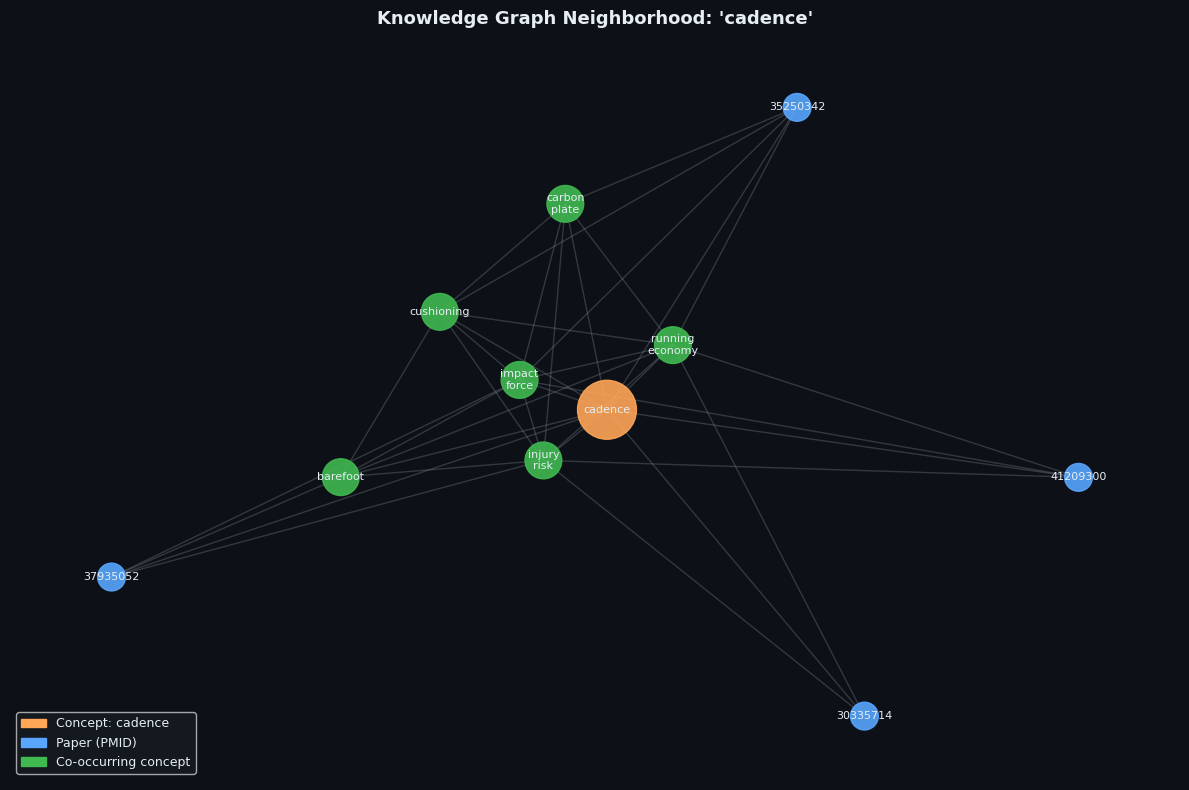

Saved → figures/08_kg_cadence.png


In [18]:
def plot_concept_neighborhood(concept: str, max_papers: int = 12) -> None:
    """
    Star-plot: concept at center, connected papers and co-concepts around it.
    """
    if concept not in G:
        print(f"'{concept}' not found in graph")
        return

    neighbors = list(G.neighbors(concept))
    papers    = [n for n in neighbors if n.startswith("PMID:")][:max_papers]
    concepts  = [n for n in neighbors if not n.startswith("PMID:")]
    nodes     = [concept] + papers + concepts

    sub = G.subgraph(nodes)
    pos = nx.spring_layout(sub, seed=7, k=1.8)
    pos[concept] = np.array([0.0, 0.0])  # pin central concept

    fig, ax = plt.subplots(figsize=(12, 8), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.axis("off")

    node_colors = []
    node_sizes  = []
    for n in sub.nodes():
        if n == concept:
            node_colors.append(ORANGE)
            node_sizes.append(1800)
        elif n.startswith("PMID:"):
            node_colors.append(BLUE)
            node_sizes.append(400)
        else:
            node_colors.append(GREEN)
            node_sizes.append(700)

    nx.draw_networkx_edges(sub, pos, alpha=0.3, edge_color=MUTED, ax=ax)
    nx.draw_networkx_nodes(sub, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.9, ax=ax)

    # Labels: short for papers, full for concepts
    labels = {}
    for n in sub.nodes():
        if n.startswith("PMID:"):
            labels[n] = n.replace("PMID:", "")  # just the ID
        else:
            labels[n] = n.replace("_", "\n")
    nx.draw_networkx_labels(sub, pos, labels=labels,
                            font_size=8, font_color="#e6edf3", ax=ax)

    legend = [
        mpatches.Patch(color=ORANGE, label=f"Concept: {concept}"),
        mpatches.Patch(color=BLUE,   label="Paper (PMID)"),
        mpatches.Patch(color=GREEN,  label="Co-occurring concept"),
    ]
    ax.legend(handles=legend, loc="lower left",
              facecolor="#161b22", labelcolor="#e6edf3", fontsize=9)

    ax.set_title(
        f"Knowledge Graph Neighborhood: '{concept}'",
        fontsize=13, fontweight="bold", color="#e6edf3", pad=14
    )
    plt.tight_layout()
    fname = f"figures/08_kg_{concept}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"Saved → {fname}")


plot_concept_neighborhood("injury_risk")
plot_concept_neighborhood("cadence")

## 9. System Summary & Portfolio Talking Points

### What was built

| Component | Implementation | Why it matters |
|-----------|---------------|----------------|
| **Real data** | PubMed E-utilities API | Reproducible, citeable, peer-reviewed |
| **RAG** | sentence-transformers + cosine similarity | Semantic retrieval, no keyword brittleness |
| **Knowledge Graph** | NetworkX concept co-occurrence | Structured relationships across the literature |
| **LLM** | Gemini Flash with grounded prompting | Cited synthesis, not hallucination |

### For wearable device companies (Garmin, Polar, WHOOP, Oura):
> This is the backbone of an **on-device or app-level evidence engine** — a coach that cites its sources. A user asking "should I change my foot strike?" gets a grounded answer from 80 peer-reviewed papers, not a generic recommendation. The knowledge graph layer lets the product surface *related* concepts ("you searched cadence — here's how it connects to injury risk").

### For consulting (Deloitte Digital Health, McKinsey Healthcare):
> The same architecture — **RAG + KG + LLM** — is the foundation of enterprise knowledge management tools. This notebook demonstrates all three components from scratch, which maps directly to consulting engagements building internal knowledge bases, clinical decision support, or regulatory evidence synthesis.

### Technical depth note:
> Production extensions: (1) replace keyword entity extraction with a fine-tuned NER model or spaCy's `en_core_sci_sm` for richer graphs; (2) add a vector store (FAISS, Chroma) for 10x faster retrieval at scale; (3) stream answers via Groq's streaming API for a real-time UX.